In [1]:
import numpy as np
from matplotlib import pyplot as plt

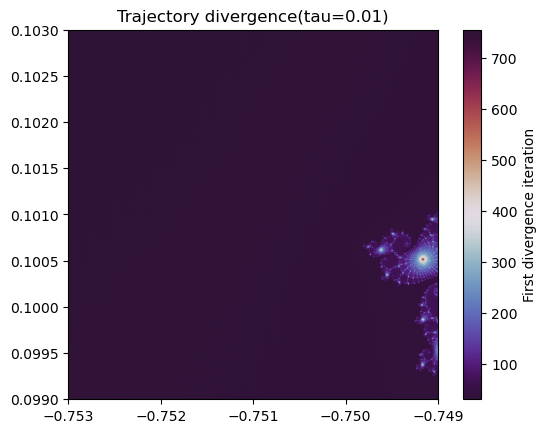

In [6]:
res = 521
max_iterations = 1000
tau = 0.01

# seahorse valley
x = np.linspace(-0.7530, -0.7490, res)
y = np.linspace(0.0990, 0.1030, res)

C64 = (x[np.newaxis, :] + 1j * y[:, np.newaxis]).astype(np.complex128)
C32 = C64.astype(np.complex64)
z32 = np.zeros_like(C32)
z64 = np.zeros_like(C64)

diverge = np.full((res, res), max_iterations, dtype=np.int32)
active = np.ones((res, res), dtype=bool)

for k in range(max_iterations):
    if not active.any(): 
        break

    z32[active] = z32[active]**2 + C32[active]
    z64[active] = z64[active]**2 + C64[active]

    diff = (np.abs(z32.real.astype(np.float64) - z64.real)
            + np.abs(z32.imag.astype(np.float64) - z64.imag))
    
    newly = active&(diff > tau)
    diverge[newly] = k
    active[newly] = False

fig, ax = plt.subplots()

im = ax.imshow(diverge, cmap='twilight_shifted', origin='lower',
                extent=[-0.7530, -0.7490, 0.0990, 0.1030])
fig.colorbar(im, ax=ax, label='First divergence iteration')
ax.set_title(f'Trajectory divergence({tau=})')

# fig.savefig("L08_Computer_Arithmetics/Trajectory_Divergence.png", dpi=300, bbox_inches='tight')

plt.show()